In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model

In [14]:
# Author: Manou Liesker. Student number: 15250946


def linear_fit(x_points, y_points, error):

    def fit_function(x, a, b):
        return a * x + b

    calibration_model = Model(fit_function)   
    calibration_model.set_param_hint('a', min= 0, max = 1)
    calibration_model.set_param_hint('b', min=-0.1, max = 0.1)

    fit_result = calibration_model.fit(y_points, x=x_points, a=0.1, b=y_points[0], weights=1/error)
    a = fit_result.params['a'].value
    b = fit_result.params['b'].value


    print(fit_result.fit_report())


    fit_y = fit_result.best_fit
    residuals = y_points - fit_y
    rmse = np.sqrt(np.mean(residuals**2))

    fig, (ax_res, ax_main) = plt.subplots(
        2, 1, figsize=(5, 4), sharex=True,
        gridspec_kw={'height_ratios': [1, 3]}
    )

    print(f'bounce height = {b} pixels')
    print(f'RMSE = {rmse:.2f} pixels')

    # residual plot
    ax_res.axhline(0, linestyle='--')
    ax_res.errorbar(x_points, residuals, yerr = error, fmt = 'o', markersize=3)
    ax_res.set_ylabel('Residual')
    ax_res.set_title(f'Fit quality (RMSE = {rmse:.2f} px)')

    # main plot
    ax_main.errorbar(x_points, y_points, label='Data', yerr=error, fmt='None', markersize=1, zorder=2)
    ax_main.plot(x_points, fit_y, label='Fit', zorder=1)


    ax_main.set_xlabel('Amount of paper layers')
    ax_main.set_ylabel('Stack height (mm)')
    ax_main.set_title('Data and fit')
    ax_main.legend()

    plt.tight_layout()
    plt.show()

    return a, b


[[Model]]
    Model(fit_function)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 21
    # variables        = 2
    chi-square         = 20.9949134
    reduced chi-square = 1.10499544
    Akaike info crit   = 3.99491280
    Bayesian info crit = 6.08395768
    R-squared          = 0.99996623
[[Variables]]
    a:  0.11365455 +/- 1.5153e-04 (0.13%) (init = 0.1)
    b:  0.04108225 +/- 0.00885720 (21.56%) (init = 0.01)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = -0.8554
bounce height = 0.041082251052011465 pixels
RMSE = 0.02 pixels


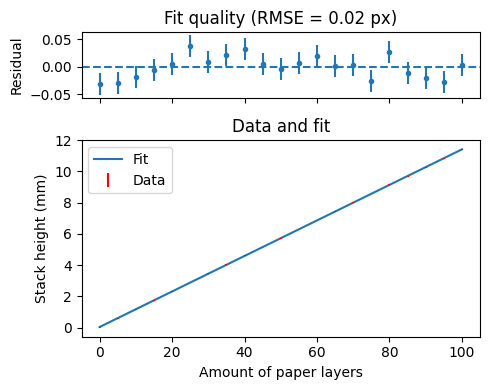

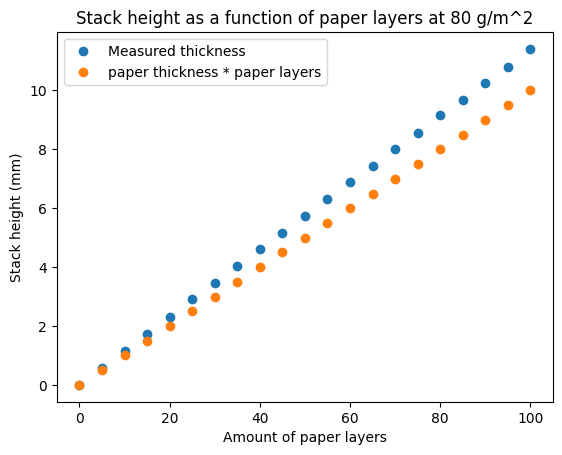

In [13]:
layers_80d = []
measured_mm_80d = [0.01, 0.58, 1.16, 1.74, 2.32, 2.92, 3.46, 4.04, 4.62, 5.16, 5.72, 6.30, 6.88, 7.43, 8.00, 8.54, 9.16, 9.69, 10.25, 10.81, 11.41]
papermm_80d = []

for i in range(0,105, 5):
    layers_80d.append(i)

for l in layers_80d:
    papermm_80d.append(0.1 * l)


linear_fit(layers_80d, measured_mm_80d, 0.02)


plt.errorbar(layers_80d, measured_mm_80d, fmt = 'o', label = 'Measured thickness')
plt.errorbar(layers_80d, papermm_80d, fmt = 'o', label = 'paper thickness * paper layers')
plt.legend()
plt.title("Stack height as a function of paper layers at 80 g/m^2")
plt.xlabel("Amount of paper layers")
plt.ylabel("Stack height (mm)")
plt.show()

19 19 19
[[Model]]
    Model(fit_function)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 19
    # variables        = 2
    chi-square         = 49.2192982
    reduced chi-square = 2.89525284
    Akaike info crit   = 22.0850894
    Bayesian info crit = 23.9739673
    R-squared          = 0.99994959
[[Variables]]
    a:  0.16554386 +/- 2.8508e-04 (0.17%) (init = 0.1)
    b: -0.00105263 +/- 0.01501749 (1426.66%) (init = 0.01)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = -0.8542
bounce height = -0.0010526319698470898 pixels
RMSE = 0.03 pixels


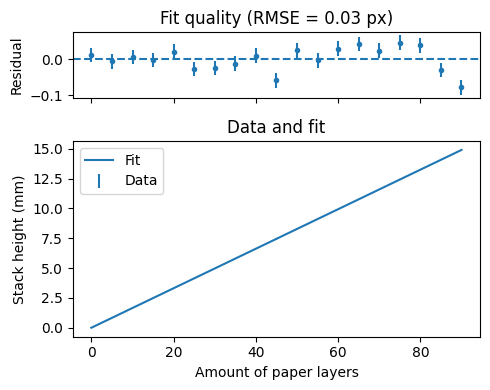

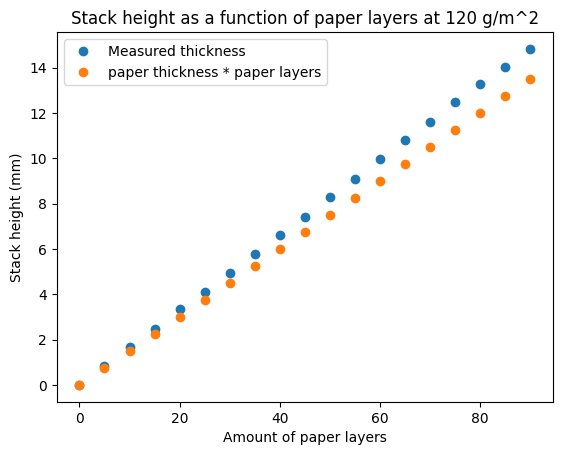

In [11]:
layers_120d = []
measured_mm_120d = [0.01, 0.82, 1.66, 2.48, 3.33, 4.11, 4.94, 5.78, 6.63, 7.39, 8.30, 9.10, 9.96, 10.80, 11.61, 12.46, 13.28, 14.04, 14.82]
papermm_120d = []

for i in range(0, 95, 5):
    layers_120d.append(i)

for l in layers_120d:
    papermm_120d.append(0.15 * l)

print(len(layers_120d), len(measured_mm_120d), len(papermm_120d))


linear_fit(layers_120d, measured_mm_120d, 0.02)


plt.errorbar(layers_120d, measured_mm_120d, fmt = 'o', label = 'Measured thickness')
plt.errorbar(layers_120d, papermm_120d, fmt = 'o', label = 'paper thickness * paper layers')
plt.legend()
plt.xlabel("Amount of paper layers")
plt.ylabel("Stack height (mm)")
plt.title("Stack height as a function of paper layers at 120 g/m^2")
plt.show()
